Importi

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score

pd.set_option('display.max_columns', None)
%matplotlib inline

Učitavanje podataka

In [2]:
df = pd.read_csv('../data/creditcard.csv')
df.shape

(284807, 31)

Informacije o podacima

In [3]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Raspodela klasa

In [4]:
class_counts = df['Class'].value_counts()
class_percent = df['Class'].value_counts(normalize=True) * 100

print(class_counts)
print()
print(class_percent)

Class
0    284315
1       492
Name: count, dtype: int64

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


Vizuelizacija raspodele klasa

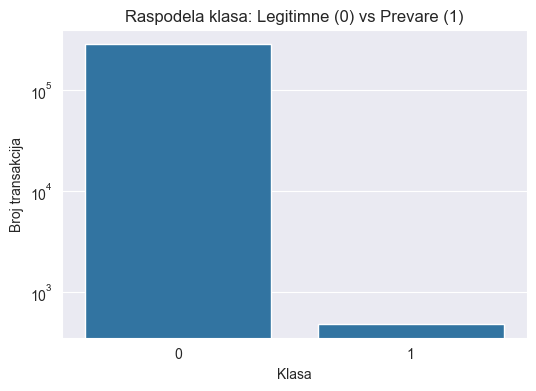

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Raspodela klasa: Legitimne (0) vs Prevare (1)')
plt.xlabel('Klasa')
plt.ylabel('Broj transakcija')
plt.yscale('log')  # log skala jer je razlika ogromna
plt.show()

Statistika za Time i Amount

In [6]:
df[['Time', 'Amount']].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


Distribucija iznosa transakcija (Amount) po klasama

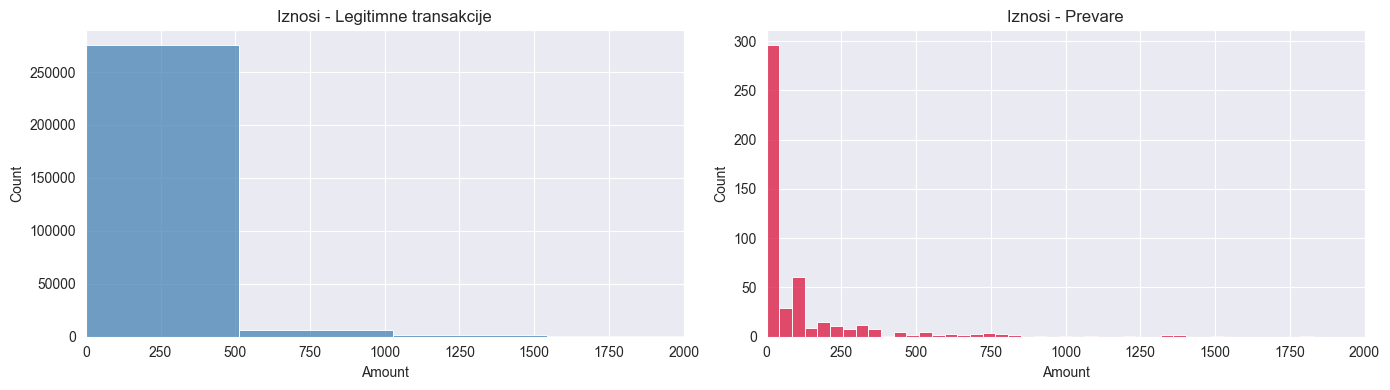

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))

sns.histplot(df[df['Class']==0]['Amount'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Iznosi - Legitimne transakcije')
axes[0].set_xlim(0, 2000)

sns.histplot(df[df['Class']==1]['Amount'], bins=50, ax=axes[1], color='crimson')
axes[1].set_title('Iznosi - Prevare')
axes[1].set_xlim(0, 2000)

plt.tight_layout()
plt.show()

Distribucija vremena po klasama

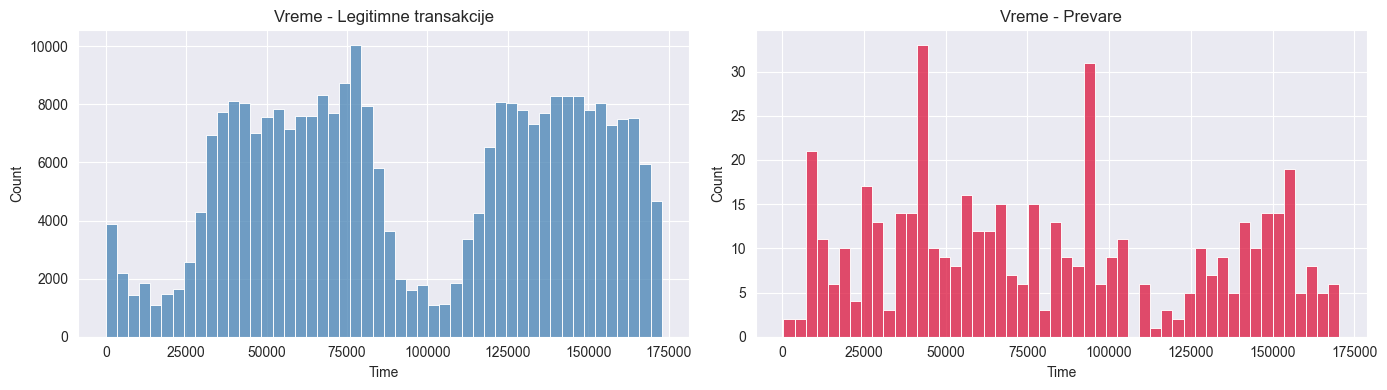

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))

sns.histplot(df[df['Class']==0]['Time'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Vreme - Legitimne transakcije')

sns.histplot(df[df['Class']==1]['Time'], bins=50, ax=axes[1], color='crimson')
axes[1].set_title('Vreme - Prevare')

plt.tight_layout()
plt.show()

Skaliranje Time i Amount

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Izbacujemo originalne kolone, zadržavamo skalirane
df = df.drop(['Time', 'Amount'], axis=1)

df[['Time_scaled', 'Amount_scaled']].describe()

,Time_scaled,Amount_scaled
count,2.848070e+05,2.848070e+05
mean,-5.109395e-17,-3.672378e-17
std,1.000002e+00,1.000002e+00
min,-1.996583e+00,-3.532294e-01
25%,-8.552120e-01,-3.308401e-01
50%,-2.131453e-01,-2.652715e-01
75%,9.372174e-01,-4.471707e-02
max,1.642058e+00,1.023622e+02


Priprema X i y

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Trening set:", X_train.shape, " | Prevare:", y_train.sum())
print("Test set:", X_test.shape, " | Prevare:", y_test.sum())

Trening set: (227845, 30)  | Prevare: 394
Test set: (56962, 30)  | Prevare: 98


SMOTE 1:3

In [11]:
from imblearn.over_sampling import SMOTE

# sampling_strategy=0.33 znači: manjinska klasa će biti ~33% (1/3) veličine većinske klase
smote = SMOTE(sampling_strategy=0.33, random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Pre SMOTE:", y_train.value_counts().to_dict())
print("Posle SMOTE:", y_train_balanced.value_counts().to_dict())

Pre SMOTE: {0: 227451, 1: 394}
Posle SMOTE: {0: 227451, 1: 75058}


Definisanje i trening baseline modela

In [12]:
from sklearn.neural_network import MLPClassifier
import time

baseline_model = MLPClassifier(
    hidden_layer_sizes=(96, 32),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=50,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=42,
    verbose=True
)

start = time.time()
baseline_model.fit(X_train_balanced, y_train_balanced)
end = time.time()

print(f"\nTrening trajao: {end - start:.1f} sekundi")
print(f"Broj epoha do zaustavljanja: {baseline_model.n_iter_}")

Iteration 1, loss = 0.04908102
Validation score: 0.997322
Iteration 2, loss = 0.00868709
Validation score: 0.998942
Iteration 3, loss = 0.00497874
Validation score: 0.999306
Iteration 4, loss = 0.00362378
Validation score: 0.999339
Iteration 5, loss = 0.00276641
Validation score: 0.998843
Iteration 6, loss = 0.00252971
Validation score: 0.999537
Iteration 7, loss = 0.00233241
Validation score: 0.999306
Iteration 8, loss = 0.00176523
Validation score: 0.999504
Iteration 9, loss = 0.00180718
Validation score: 0.999471
Iteration 10, loss = 0.00145719
Validation score: 0.999504
Iteration 11, loss = 0.00181374
Validation score: 0.999240
Iteration 12, loss = 0.00131712
Validation score: 0.999504
Iteration 13, loss = 0.00114023
Validation score: 0.999669
Iteration 14, loss = 0.00114373
Validation score: 0.999636
Iteration 15, loss = 0.00138553
Validation score: 0.999240
Iteration 16, loss = 0.00126844
Validation score: 0.999603
Iteration 17, loss = 0.00105214
Validation score: 0.999570
Iterat

Predikcije i osnovne metrike

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = baseline_model.predict(X_test)
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Legitimna', 'Prevara']))
print(f"\nAUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")

              precision    recall  f1-score   support

   Legitimna       1.00      1.00      1.00     56864
     Prevara       0.76      0.79      0.77        98

    accuracy                           1.00     56962
   macro avg       0.88      0.89      0.89     56962
weighted avg       1.00      1.00      1.00     56962


AUC-ROC: 0.9715


Confusion matrix

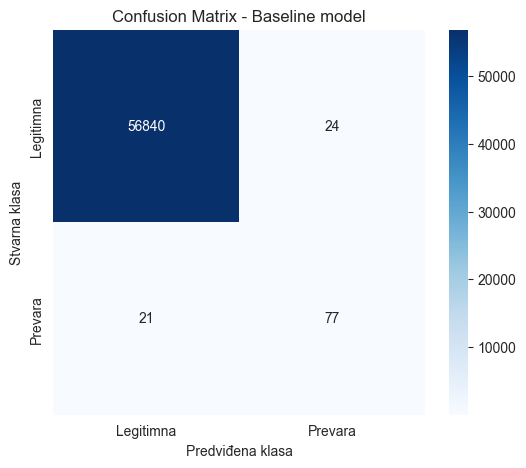

True Negative (ispravno legitimna): 56840
False Positive (lažna uzbuna):      24
False Negative (propuštena prevara): 21
True Positive (uhvaćena prevara):    77


In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimna', 'Prevara'],
            yticklabels=['Legitimna', 'Prevara'])
plt.title('Confusion Matrix - Baseline model')
plt.ylabel('Stvarna klasa')
plt.xlabel('Predviđena klasa')
plt.show()

# Detaljnije objašnjenje brojeva
tn, fp, fn, tp = cm.ravel()
print(f"True Negative (ispravno legitimna): {tn}")
print(f"False Positive (lažna uzbuna):      {fp}")
print(f"False Negative (propuštena prevara): {fn}")
print(f"True Positive (uhvaćena prevara):    {tp}")

 Grid pretraga hiperparametara (15 kombinacija)

In [15]:
import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score

param_combinations = [
    {'hidden_layer_sizes': (96, 32),       'activation': 'relu', 'learning_rate_init': 0.001},   # baseline
    {'hidden_layer_sizes': (96, 32),       'activation': 'relu', 'learning_rate_init': 0.01},
    {'hidden_layer_sizes': (96, 32),       'activation': 'relu', 'learning_rate_init': 0.0001},
    {'hidden_layer_sizes': (96, 32),       'activation': 'tanh', 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (64, 32, 16),   'activation': 'relu', 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (64, 32, 16),   'activation': 'relu', 'learning_rate_init': 0.01},
    {'hidden_layer_sizes': (64, 32, 16),   'activation': 'tanh', 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (128, 64),      'activation': 'relu', 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (128, 64),      'activation': 'tanh', 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (128, 64, 32),  'activation': 'relu', 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (128, 64, 32),  'activation': 'relu', 'learning_rate_init': 0.01},
    {'hidden_layer_sizes': (50, 25),       'activation': 'relu', 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (50, 25),       'activation': 'relu', 'learning_rate_init': 0.0001},
    {'hidden_layer_sizes': (50, 25),       'activation': 'tanh', 'learning_rate_init': 0.001},
    {'hidden_layer_sizes': (150, 75, 30),  'activation': 'relu', 'learning_rate_init': 0.001},
]

results = []

for i, params in enumerate(param_combinations):
    print(f"--- Kombinacija {i+1}/{len(param_combinations)}: {params} ---")

    model = MLPClassifier(
        hidden_layer_sizes=params['hidden_layer_sizes'],
        activation=params['activation'],
        learning_rate_init=params['learning_rate_init'],
        max_iter=50,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=42,
        verbose=False
    )

    model.fit(X_train_balanced, y_train_balanced)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        'hidden_layer_sizes': str(params['hidden_layer_sizes']),
        'activation': params['activation'],
        'learning_rate_init': params['learning_rate_init'],
        'F1': round(f1, 4),
        'AUC-ROC': round(auc, 4),
        'n_iter': model.n_iter_
    })

    print(f"F1: {f1:.4f} | AUC-ROC: {auc:.4f} | Epohe: {model.n_iter_}\n")

results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
results_df

--- Kombinacija 1/15: {'hidden_layer_sizes': (96, 32), 'activation': 'relu', 'learning_rate_init': 0.001} ---
F1: 0.7739 | AUC-ROC: 0.9715 | Epohe: 24

--- Kombinacija 2/15: {'hidden_layer_sizes': (96, 32), 'activation': 'relu', 'learning_rate_init': 0.01} ---
F1: 0.7345 | AUC-ROC: 0.9707 | Epohe: 20

--- Kombinacija 3/15: {'hidden_layer_sizes': (96, 32), 'activation': 'relu', 'learning_rate_init': 0.0001} ---
F1: 0.7200 | AUC-ROC: 0.9719 | Epohe: 32

--- Kombinacija 4/15: {'hidden_layer_sizes': (96, 32), 'activation': 'tanh', 'learning_rate_init': 0.001} ---
F1: 0.7339 | AUC-ROC: 0.9664 | Epohe: 26

--- Kombinacija 5/15: {'hidden_layer_sizes': (64, 32, 16), 'activation': 'relu', 'learning_rate_init': 0.001} ---
F1: 0.7826 | AUC-ROC: 0.9701 | Epohe: 23

--- Kombinacija 6/15: {'hidden_layer_sizes': (64, 32, 16), 'activation': 'relu', 'learning_rate_init': 0.01} ---
F1: 0.6891 | AUC-ROC: 0.9750 | Epohe: 16

--- Kombinacija 7/15: {'hidden_layer_sizes': (64, 32, 16), 'activation': 'tanh', 

,hidden_layer_sizes,activation,learning_rate_init,F1,AUC-ROC,n_iter
14,"(150, 75, 30)",relu,0.0010,0.8182,0.9731,27
7,"(128, 64)",relu,0.0010,0.8000,0.9672,20
8,"(128, 64)",tanh,0.0010,0.8000,0.9548,20
4,"(64, 32, 16)",relu,0.0010,0.7826,0.9701,23
0,"(96, 32)",relu,0.0010,0.7739,0.9715,24
9,"(128, 64, 32)",relu,0.0010,0.7535,0.9722,15
11,"(50, 25)",relu,0.0010,0.7373,0.9727,15
1,"(96, 32)",relu,0.0100,0.7345,0.9707,20
3,"(96, 32)",tanh,0.0010,0.7339,0.9664,26
2,"(96, 32)",relu,0.0001,0.7200,0.9719,32


Finalni optimizovani model

In [16]:
final_model = MLPClassifier(
    hidden_layer_sizes=(150, 75, 30),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=50,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=42,
    verbose=True
)

final_model.fit(X_train_balanced, y_train_balanced)

Iteration 1, loss = 0.02752858
Validation score: 0.998579
Iteration 2, loss = 0.00608432
Validation score: 0.999174
Iteration 3, loss = 0.00392651
Validation score: 0.998149
Iteration 4, loss = 0.00338538
Validation score: 0.999174
Iteration 5, loss = 0.00300050
Validation score: 0.999207
Iteration 6, loss = 0.00229667
Validation score: 0.999405
Iteration 7, loss = 0.00311358
Validation score: 0.999405
Iteration 8, loss = 0.00189766
Validation score: 0.998711
Iteration 9, loss = 0.00198529
Validation score: 0.999107
Iteration 10, loss = 0.00173256
Validation score: 0.999537
Iteration 11, loss = 0.00137175
Validation score: 0.999041
Iteration 12, loss = 0.00152060
Validation score: 0.998182
Iteration 13, loss = 0.00151935
Validation score: 0.999405
Iteration 14, loss = 0.00126478
Validation score: 0.999405
Iteration 15, loss = 0.00123011
Validation score: 0.999636
Iteration 16, loss = 0.00103286
Validation score: 0.999769
Iteration 17, loss = 0.00072429
Validation score: 0.999636
Iterat

,hidden_layer_sizes,"(150, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,50
,shuffle,True
,random_state,42


Evaluacija finalnog modela

In [17]:
y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:, 1]

print("=== FINALNI (OPTIMIZOVANI) MODEL ===")
print(classification_report(y_test, y_pred_final, target_names=['Legitimna', 'Prevara']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_final):.4f}")

=== FINALNI (OPTIMIZOVANI) MODEL ===
              precision    recall  f1-score   support

   Legitimna       1.00      1.00      1.00     56864
     Prevara       0.81      0.83      0.82        98

    accuracy                           1.00     56962
   macro avg       0.90      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9731


Confusion matrix - finalni model

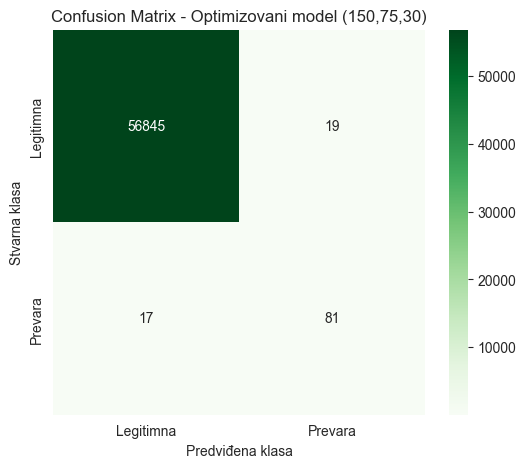

True Negative:  56845
False Positive: 19  (lažna uzbuna)
False Negative: 17  (propuštena prevara)
True Positive:  81  (uhvaćena prevara)


In [18]:
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legitimna', 'Prevara'],
            yticklabels=['Legitimna', 'Prevara'])
plt.title('Confusion Matrix - Optimizovani model (150,75,30)')
plt.ylabel('Stvarna klasa')
plt.xlabel('Predviđena klasa')
plt.show()

tn, fp, fn, tp = cm_final.ravel()
print(f"True Negative:  {tn}")
print(f"False Positive: {fp}  (lažna uzbuna)")
print(f"False Negative: {fn}  (propuštena prevara)")
print(f"True Positive:  {tp}  (uhvaćena prevara)")

Poređenje baseline vs optimizovani

In [22]:
#Poređenje baseline vs optimizovani — sveže predikcije
y_pred_baseline_fresh = baseline_model.predict(X_test)
y_proba_baseline_fresh = baseline_model.predict_proba(X_test)[:, 1]

y_pred_final_fresh = final_model.predict(X_test)
y_proba_final_fresh = final_model.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame({
    'Model': ['Baseline (96,32)', 'Optimizovani (150,75,30)'],
    'Precision': [
        precision_score(y_test, y_pred_baseline_fresh),
        precision_score(y_test, y_pred_final_fresh)
    ],
    'Recall': [
        recall_score(y_test, y_pred_baseline_fresh),
        recall_score(y_test, y_pred_final_fresh)
    ],
    'F1': [
        f1_score(y_test, y_pred_baseline_fresh),
        f1_score(y_test, y_pred_final_fresh)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_proba_baseline_fresh),
        roc_auc_score(y_test, y_proba_final_fresh)
    ]
})

comparison

,Model,Precision,Recall,F1,AUC-ROC
0,"Baseline (96,32)",0.762376,0.785714,0.773869,0.971492
1,"Optimizovani (150,75,30)",0.810000,0.826531,0.818182,0.973146


In [23]:
#Provera da li su y_pred i y_pred_final stvarno različiti
print("Da li su y_pred i y_pred_final identični?", (y_pred == y_pred_final).all())
print("Broj različitih predikcija:", (y_pred != y_pred_final).sum())

print("\ny_pred (baseline) - broj prevara predviđenih:", y_pred.sum())
print("y_pred_final (optimizovani) - broj prevara predviđenih:", y_pred_final.sum())

Da li su y_pred i y_pred_final identični? True
Broj različitih predikcija: 0

y_pred (baseline) - broj prevara predviđenih: 100
y_pred_final (optimizovani) - broj prevara predviđenih: 100


In [21]:
# Provera identiteta modela i predikcija
print("Da li su baseline_model i final_model isti objekat?", baseline_model is final_model)
print()
print("Predikcije baseline_model.predict(X_test) sad:")
test_pred = baseline_model.predict(X_test)
print("Broj prevara:", test_pred.sum())
print("Da li se ovo poklapa sa postojećim y_pred?", (test_pred == y_pred).all())
print()
print("hidden_layer_sizes baseline_model:", baseline_model.hidden_layer_sizes)
print("hidden_layer_sizes final_model:", final_model.hidden_layer_sizes)

Da li su baseline_model i final_model isti objekat? False

Predikcije baseline_model.predict(X_test) sad:
Broj prevara: 101
Da li se ovo poklapa sa postojećim y_pred? False

hidden_layer_sizes baseline_model: (96, 32)
hidden_layer_sizes final_model: (150, 75, 30)


Logistička regresija - poređenje

In [24]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_balanced, y_train_balanced)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("=== LOGISTIČKA REGRESIJA ===")
print(classification_report(y_test, y_pred_lr, target_names=['Legitimna', 'Prevara']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_lr):.4f}")

=== LOGISTIČKA REGRESIJA ===
              precision    recall  f1-score   support

   Legitimna       1.00      0.99      1.00     56864
     Prevara       0.15      0.90      0.26        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.63     56962
weighted avg       1.00      0.99      0.99     56962

AUC-ROC: 0.9680
